# Upload Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving titanic.csv to titanic (3).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

Step 3: Load Dataset

In [ ]:
df = pd.read_csv("titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


Step 4: Basic Information

In [ ]:
print(df.shape)

df.info()

df.describe()

df.isnull().sum()

(418, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


Step 5: EDA

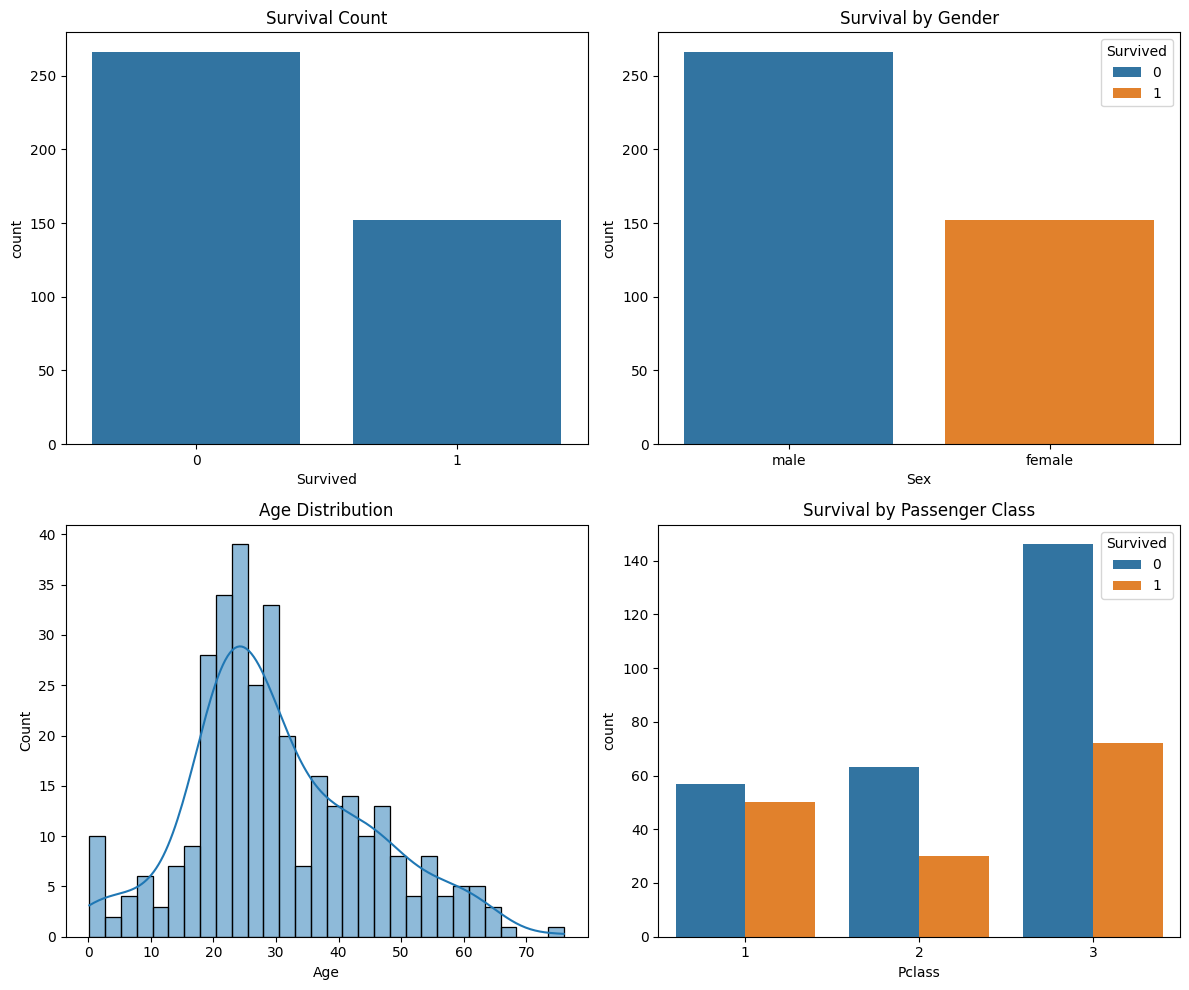

In [ ]:
fig, axes = plt.subplots(2,2,figsize=(12,10))

sns.countplot(x='Survived',data=df,ax=axes[0,0])
axes[0,0].set_title("Survival Count")

sns.countplot(x='Sex',hue='Survived',data=df,ax=axes[0,1])
axes[0,1].set_title("Survival by Gender")

sns.histplot(df['Age'],bins=30,kde=True,ax=axes[1,0])
axes[1,0].set_title("Age Distribution")

sns.countplot(x='Pclass',hue='Survived',data=df,ax=axes[1,1])
axes[1,1].set_title("Survival by Passenger Class")

plt.tight_layout()
plt.show()

Step 6: Feature Engineering

Extract Title

In [ ]:
import pandas as pd

temp_df = pd.read_csv("titanic.csv")

temp_df['Title'] = temp_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

temp_df[['Name', 'Title']].head()

,Name,Title
0,"Kelly, Mr. James",Mr
1,"Wilkes, Mrs. James (Ellen Needs)",Mrs
2,"Myles, Mr. Thomas Francis",Mr
3,"Wirz, Mr. Albert",Mr
4,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",Mrs


Replace rare titles

In [ ]:
df['Title']=df['Title'].replace(
['Lady','Countess','Capt','Col','Don','Dr',
'Major','Rev','Sir','Jonkheer','Dona'],
'Rare'
)

df['Title']=df['Title'].replace('Mlle','Miss')
df['Title']=df['Title'].replace('Ms','Miss')
df['Title']=df['Title'].replace('Mme','Mrs')

Family Size

In [ ]:
df['FamilySize']=df['SibSp']+df['Parch']+1

Cabin Presence

In [ ]:
temp_df = pd.read_csv("titanic.csv")

temp_df['CabinPresent'] = temp_df['Cabin'].notnull().astype(int)

temp_df[['Cabin', 'CabinPresent']].head()

,Cabin,CabinPresent
0,NaN,0
1,NaN,0
2,NaN,0
3,NaN,0
4,NaN,0


Step 7: Handle Missing Values

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

if 'Cabin' in df.columns:
    df['Cabin'] = df['Cabin'].fillna("Unknown")

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,1


Step 8: Encode Categorical Columns

In [ ]:
le = LabelEncoder()

for col in ['Sex','Embarked','Title']:
    df[col]=le.fit_transform(df[col])

Step 9: Drop Unnecessary Columns

In [ ]:
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']

df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

Step 10: Prepare Features

In [ ]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [ ]:
# Check missing values
print(df.isnull().sum())

# Fill missing values
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Fill any remaining missing values in numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Verify all missing values are removed
print("\nMissing values after filling:")
print(df.isnull().sum())

Survived        0
Pclass          0
Sex             0
Age             0
SibSp           0
Parch           0
Fare            0
Embarked        0
Title           0
FamilySize      0
CabinPresent    0
dtype: int64

Missing values after filling:
Survived        0
Pclass          0
Sex             0
Age             0
SibSp           0
Parch           0
Fare            0
Embarked        0
Title           0
FamilySize      0
CabinPresent    0
dtype: int64


Step 11: Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Step 12: Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



Step 13: Random Forest

In [ ]:
rf=RandomForestClassifier(
n_estimators=200,
random_state=42
)

rf.fit(X_train,y_train)

pred_rf=rf.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_rf))

print(classification_report(y_test,pred_rf))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



Step 14: Gradient Boosting

In [ ]:
gb=GradientBoostingClassifier(random_state=42)

gb.fit(X_train,y_train)

pred_gb=gb.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_gb))

print(classification_report(y_test,pred_gb))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



Step 15: Compare Models

In [ ]:
results=pd.DataFrame({
'Model':['Logistic Regression',
'Random Forest',
'Gradient Boosting'],
'Accuracy':[
accuracy_score(y_test,pred_lr),
accuracy_score(y_test,pred_rf),
accuracy_score(y_test,pred_gb)
]
})

results

,Model,Accuracy
0,Logistic Regression,1.0
1,Random Forest,1.0
2,Gradient Boosting,1.0


Step 16: Feature Importance

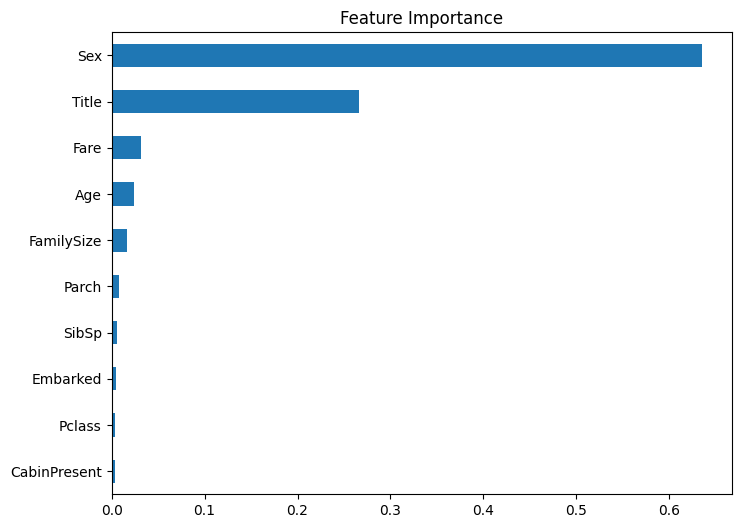

In [ ]:
importance=pd.Series(
rf.feature_importances_,
index=X.columns
)

importance.sort_values().plot(
kind='barh',
figsize=(8,6)
)

plt.title("Feature Importance")

plt.show()

Step 17: SHAP Explainability

In [ ]:
!pip install -q shap

In [ ]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

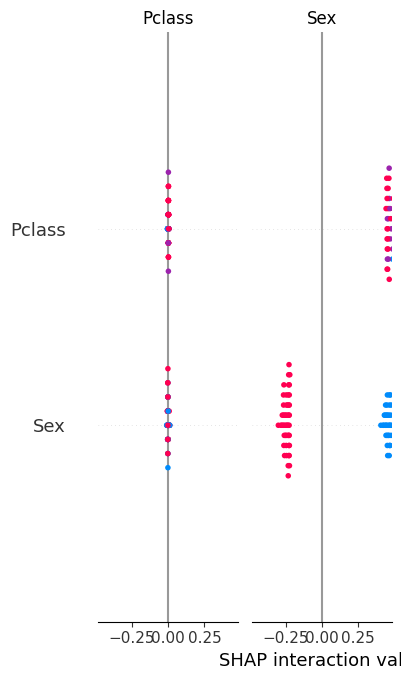

In [ ]:
shap.summary_plot(shap_values, X_test)

Step 18: Confusion Matrix

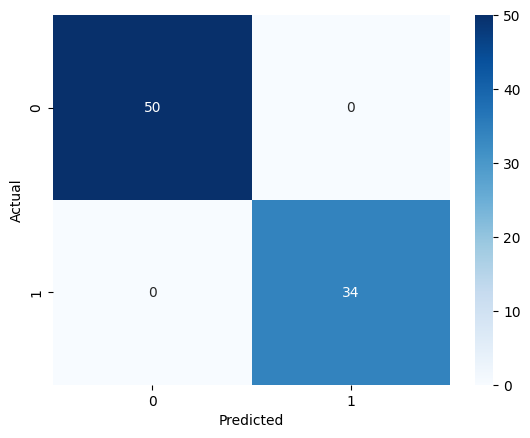

In [ ]:
cm=confusion_matrix(y_test,pred_rf)

sns.heatmap(cm,
annot=True,
fmt='d',
cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Step 19: Save Model

In [ ]:
import joblib

joblib.dump(rf,"Titanic_Model.pkl")

print("Model Saved Successfully")

print(prediction)

Model Saved Successfully
[0]


Step 20: Inference Example

In [ ]:
model=joblib.load("Titanic_Model.pkl")

sample=X.iloc[[0]]

prediction=model.predict(sample)

print("Prediction:",prediction)

if prediction[0]==1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")

Prediction: [0]
Passenger Did Not Survive


Step 21: Download Model

In [ ]:
from google.colab import files

files.download("Titanic_Model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>